<a href="https://colab.research.google.com/github/amanpoonia/IV_closedform_BlackScholes/blob/main/GEV_distributions_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bollinger Band

Definition: Set upper/lower bound using standar devaiation around a moving average.

Steps:
1) get data for the asset for past five years
2) get the moving average of the last 20 days.(This should be at the top of the code in order to change the value to last x day average)
3) calculate the std deviation bounds for each day(each data points)
4) Plot the MA, and the upper/lower bounds

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
symbol = 'ITC.NS'
price_data = yf.download(symbol, start = '2012-01-01', end = '2026-04-15')
price_data.head()

/tmp/ipykernel_1679/3284410928.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(symbol, start = '2012-01-01', end = '2026-04-15')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ITC.NS,ITC.NS,ITC.NS,ITC.NS,ITC.NS
Date,,,,,
2012-01-02,82.652588,83.984018,82.340537,83.984018,2971018
2012-01-03,83.359909,83.859200,82.923038,83.151875,6299194
2012-01-04,83.027069,83.921619,82.590193,83.838406,12332428
2012-01-05,83.131081,83.214294,82.215722,82.819025,11802169
2012-01-06,84.088043,84.504111,82.527771,82.819023,9126672


In [ ]:
itc_data = price_data[['Close', 'Volume']].copy()
display(itc_data.head())

Price,Close,Volume
Ticker,ITC.NS,ITC.NS
Date,,
2012-01-02,82.652588,2971018
2012-01-03,83.359909,6299194
2012-01-04,83.027069,12332428
2012-01-05,83.131081,11802169
2012-01-06,84.088043,9126672


In [ ]:
itc_data['MA'] = itc_data['Close'].rolling(window=20).mean()
print(f"Number of NaN values in 'MA' column after 20-day MA calculation: {itc_data['MA'].isnull().sum()}")

/tmp/ipykernel_1679/1886421411.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  itc_data['MA'] = itc_data['Close'].rolling(window=10).mean()


Price,Close,Volume,MA
Ticker,ITC.NS,ITC.NS,
Date,,,
2012-01-02,82.652588,2971018,NaN
2012-01-03,83.359909,6299194,NaN
2012-01-04,83.027069,12332428,NaN
2012-01-05,83.131081,11802169,NaN
2012-01-06,84.088043,9126672,NaN
2012-01-09,84.046448,7693555,NaN
2012-01-10,85.357079,5620843,NaN
2012-01-11,84.587318,8426514,NaN


Number of NaN values in 'MA' column: 3521


In [ ]:
# This cell previously recalculated the MA with a different window size. It has been commented out to avoid conflicts.

/tmp/ipykernel_1679/1870006418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  itc_data['MA'] = itc_data['Close'].rolling(window = 5).mean()


Price,Close,Volume,MA
Ticker,ITC.NS,ITC.NS,
Date,,,
2012-01-02,82.652588,2971018,NaN
2012-01-03,83.359909,6299194,NaN
2012-01-04,83.027069,12332428,NaN
2012-01-05,83.131081,11802169,NaN
2012-01-06,84.088043,9126672,NaN
2012-01-09,84.046448,7693555,NaN
2012-01-10,85.357079,5620843,NaN
2012-01-11,84.587318,8426514,NaN


In [ ]:
itc_data.dropna(inplace = True)
display(itc_data.head())
print(f"Shape of itc_data after dropping NaNs: {itc_data.shape}")

## Generalized Extreme Value (GEV) Distribution

This section demonstrates how to define, parameterize, and visualize a GEV distribution, allowing you to tweak its shape, location, and scale.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme


In [ ]:
# GEV Distribution Parameters
# c: shape parameter (xi or k)
# loc: location parameter (mu)
# scale: scale parameter (sigma)

# You can modify these values to observe changes in the distribution
shape_param = 0.1  # Example: positive shape
# shape_param = -0.2 # Example: negative shape
# shape_param = 0.0  # Example: Gumbel distribution (shape = 0)

location_param = 0  # Mean of the distribution
scale_param = 1   # Spread of the distribution

print(f"GEV Parameters: Shape = {shape_param}, Location = {location_param}, Scale = {scale_param}")


In [ ]:
# Generate x values for the plot
x = np.linspace(genextreme.ppf(0.001, shape_param, loc=location_param, scale=scale_param),
                genextreme.ppf(0.999, shape_param, loc=location_param, scale=scale_param), 100)

# Calculate the Probability Density Function (PDF)
pdf_values = genextreme.pdf(x, shape_param, loc=location_param, scale=scale_param)

# Calculate the Cumulative Distribution Function (CDF)
cdf_values = genextreme.cdf(x, shape_param, loc=location_param, scale=scale_param)

# Plotting the PDF and CDF
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Subplot for PDF
plt.plot(x, pdf_values, 'r-', lw=2, alpha=0.6, label='GEV PDF')
plt.title('Generalized Extreme Value (GEV) Distribution PDF')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # Subplot for CDF
plt.plot(x, cdf_values, 'b-', lw=2, alpha=0.6, label='GEV CDF')
plt.title('Generalized Extreme Value (GEV) Distribution CDF')
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Manual GEV Distribution Implementation

Now, let's implement the GEV PDF and CDF functions manually, without relying on `scipy.stats`, so you can see the underlying formulas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gev_pdf(x, c, loc, scale):
    """Generalized Extreme Value (GEV) probability density function (PDF)."""
    if scale <= 0:
        raise ValueError("Scale parameter must be positive.")

    if c == 0:  # Gumbel distribution
        t = (x - loc) / scale
        return (1 / scale) * np.exp(-t - np.exp(-t))
    else:
        y = (x - loc) / scale
        term = 1 + c * y
        # Handle cases where term <= 0, as GEV is not defined for these values
        # For negative c, there's an upper bound; for positive c, a lower bound.
        # This simple implementation will return 0 for undefined regions.
        pdf_values = np.zeros_like(x, dtype=float)
        valid_indices = term > 0

        if np.any(valid_indices): # Only calculate where term is positive
            term_valid = term[valid_indices]
            pdf_values[valid_indices] = (1 / scale) * (term_valid)**(-1/c - 1) * np.exp(-(term_valid)**(-1/c))
        return pdf_values

def gev_cdf(x, c, loc, scale):
    """Generalized Extreme Value (GEV) cumulative distribution function (CDF)."""
    if scale <= 0:
        raise ValueError("Scale parameter must be positive.")

    if c == 0:  # Gumbel distribution
        t = (x - loc) / scale
        return np.exp(-np.exp(-t))
    else:
        y = (x - loc) / scale
        term = 1 + c * y
        # Handle cases where term <= 0
        cdf_values = np.zeros_like(x, dtype=float)

        if c > 0: # Frechet distribution (lower bound)
            valid_indices = term > 0
            if np.any(valid_indices):
                term_valid = term[valid_indices]
                cdf_values[valid_indices] = np.exp(-(term_valid)**(-1/c))
            # For x < loc - scale/c, CDF is 0, which is handled by zeros_like initially
            return cdf_values
        else: # Weibull distribution (upper bound)
            valid_indices = term > 0
            if np.any(valid_indices):
                term_valid = term[valid_indices]
                cdf_values[valid_indices] = np.exp(-(term_valid)**(-1/c))
            # For x > loc - scale/c, CDF is 1. We need to set these values.
            cdf_values[~valid_indices] = 1.0 # For the part where term <= 0
            return cdf_values

### GEV Distribution Formulas (Symbolic Form)

The Generalized Extreme Value (GEV) distribution is defined by three parameters: shape $c$ (sometimes denoted as $\xi$ or $k$), location $\mu$, and scale $\sigma > 0$.

Let $y = \frac{x - \mu}{\sigma}$.

#### Probability Density Function (PDF)

*   **For $c \neq 0$:**
    $$f(x; c, \mu, \sigma) = \frac{1}{\sigma} \left( 1 + c y \right)^{-1/c - 1} \exp\left( -\left( 1 + c y \right)^{-1/c} \right)$$
    This is valid for $1 + c y > 0$.

*   **For $c = 0$ (Gumbel distribution):**
    $$f(x; 0, \mu, \sigma) = \frac{1}{\sigma} \exp\left( -y - \exp(-y) \right)$$

#### Cumulative Distribution Function (CDF)

*   **For $c \neq 0$:**
    $$F(x; c, \mu, \sigma) = \exp\left( -\left( 1 + c y \right)^{-1/c} \right)$$
    This is valid for $1 + c y > 0$.

*   **For $c = 0$ (Gumbel distribution):**
    $$F(x; 0, \mu, \sigma) = \exp\left( -\exp(-y) \right)$$

These formulas are the basis for the manual `gev_pdf` and `gev_cdf` functions implemented above.

Manual GEV Parameters: Shape = 0.1, Location = 0, Scale = 1


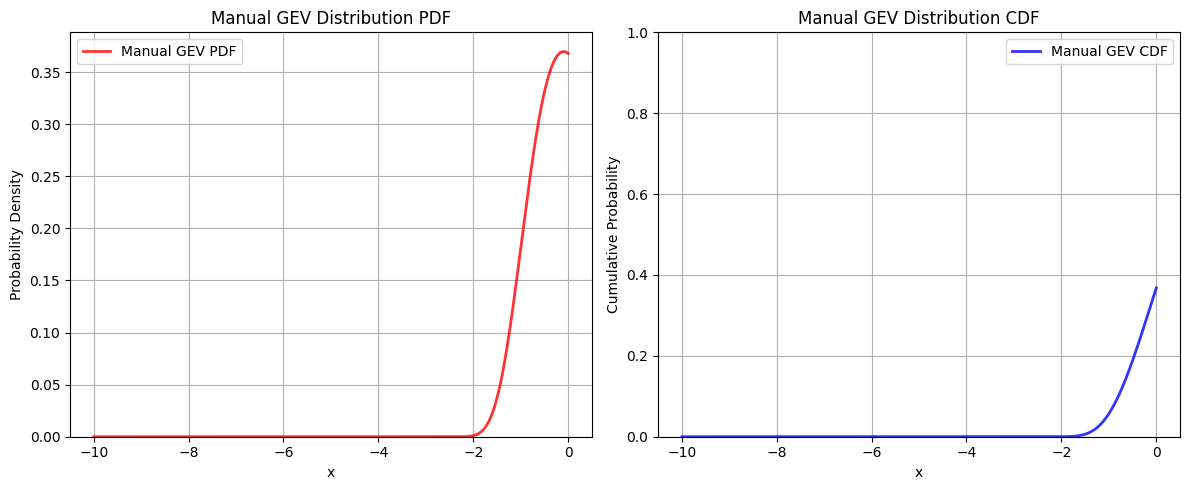

In [ ]:
# Use the same GEV Distribution Parameters as before
# You can modify these values to observe changes in the distribution
shape_param = 0.1  # Example: positive shape
# shape_param = -0.2 # Example: negative shape
# shape_param = 0.0  # Example: Gumbel distribution (shape = 0)

location_param = 0  # Mean of the distribution
scale_param = 1   # Spread of the distribution

print(f"Manual GEV Parameters: Shape = {shape_param}, Location = {location_param}, Scale = {scale_param}")

# Generate x values for the plot manually. Adjust range for different shapes if needed.
# For c > 0 (Frechet), there's a lower bound at loc - scale/c.
# For c < 0 (Weibull), there's an upper bound at loc - scale/c.
# For c = 0 (Gumbel), it's unbounded.

if shape_param > 0: # Frechet type (has a lower bound)
    lower_bound = location_param - scale_param / shape_param
    x_min = lower_bound + 0.001 * scale_param # Start slightly above the lower bound
    x_max = lower_bound + 10 * scale_param    # Extend significantly beyond the bound
elif shape_param < 0: # Weibull type (has an upper bound)
    upper_bound = location_param - scale_param / shape_param
    x_max = upper_bound - 0.001 * scale_param # End slightly below the upper bound
    x_min = upper_bound - 10 * scale_param    # Extend significantly before the bound
else: # Gumbel type (c = 0)
    x_min = location_param - 5 * scale_param
    x_max = location_param + 5 * scale_param

x = np.linspace(x_min, x_max, 500) # Use more points for smoother curve

# Calculate the Probability Density Function (PDF) using our custom function
pdf_values_manual = gev_pdf(x, shape_param, loc=location_param, scale=scale_param)

# Calculate the Cumulative Distribution Function (CDF) using our custom function
cdf_values_manual = gev_cdf(x, shape_param, loc=location_param, scale=scale_param)

# Plotting the PDF and CDF
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Subplot for PDF
plt.plot(x, pdf_values_manual, 'r-', lw=2, alpha=0.8, label='Manual GEV PDF')
plt.title('Manual GEV Distribution PDF')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure PDF doesn't go below 0

plt.subplot(1, 2, 2) # Subplot for CDF
plt.plot(x, cdf_values_manual, 'b-', lw=2, alpha=0.8, label='Manual GEV CDF')
plt.title('Manual GEV Distribution CDF')
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)
plt.ylim(0, 1) # Ensure CDF stays between 0 and 1

plt.tight_layout()
plt.show()

Plot the GEV(generalized extreme values) distribution

pdf, f(x) is a function of

1.   zeta : shape parameter (z)
2.   meu : location parametr (u)
3.   sigma : scale parameter (sigma)





In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
def pdf(z, u, sigma):

  if sigma<=0:
    return print("ERROR")
  else:
    if z != 0:



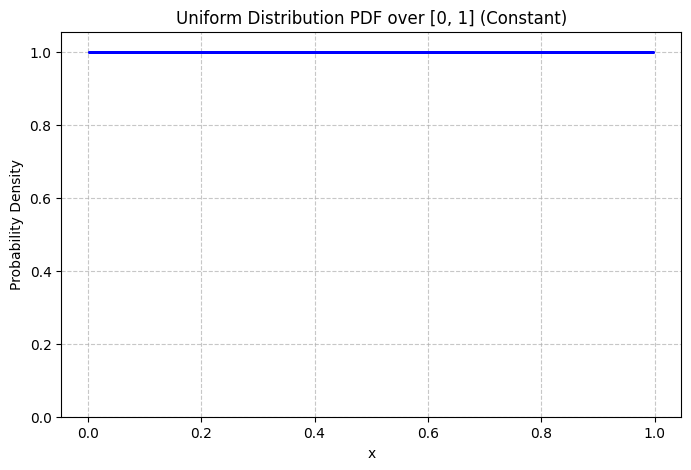

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for the uniform distribution
a = 0
b = 1

# Generate x values only within the range [a, b]
x = np.random.uniform(a, b, 500)

# Calculate the PDF value, which is constant over the range [a, b]
# And create 'y' as an array of this constant value using np.ones_like

y = np.ones_like(x) * 1 / (b - a)

# Plotting the uniform distribution PDF
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', linestyle='-', linewidth=2)
plt.title(f'Uniform Distribution PDF over [{a}, {b}] (Constant)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for the uniform distribution
a = 0
b = 1

# Generate x values for the plot. For a uniform distribution, we are plotting
# the probability density, which is constant over the range [a, b].
# We'll use a linspace for x values to show the constant PDF more clearly.
x = np.linspace(a - 0.5, b + 0.5, 500) # Extend range slightly beyond [a, b] for visualization

# Calculate the PDF values. The PDF is 1/(b-a) for x in [a, b] and 0 otherwise.
y = np.where((x >= a) & (x <= b), 1/(b-a), 0)

# Plotting the uniform distribution PDF
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', linestyle='-', linewidth=2)
plt.title(f'Uniform Distribution PDF over [{a}, {b}]')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

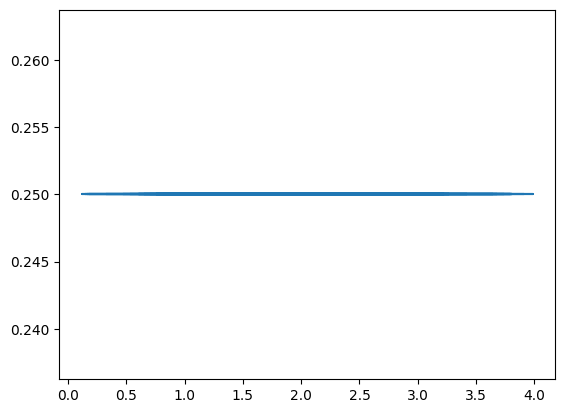

In [ ]:
a = 0
b = 4

pdf = 1/(b-a)

x = np.random.uniform(a,b,100)
y = np.ones_like(x) * pdf

plt.plot(x,y)

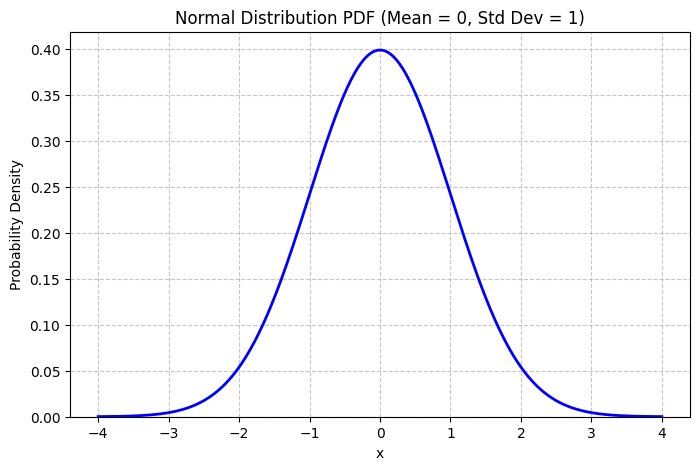

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters for the normal distribution
u = 0     # Mean
sigma = 1 # Standard deviation

# Generate x values for the plot to get a smooth curve
x = np.linspace(u - 4 * sigma, u + 4 * sigma, 500) # 500 points between -4*sigma and +4*sigma from the mean

# Calculate the Probability Density Function (PDF) for the normal distribution
pdf = (1 / (np.sqrt(2 * np.pi * sigma**2))) * np.exp(-((x - u)**2 / (2 * sigma**2)))

# Plotting the normal distribution PDF
plt.figure(figsize=(8, 5))
plt.plot(x, pdf, color='blue', linestyle='-', linewidth=2)
plt.title(f'Normal Distribution PDF (Mean = {u}, Std Dev = {sigma})')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

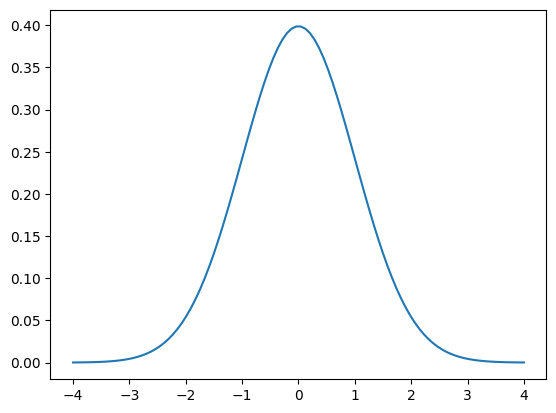

In [ ]:
u = 0
sigma = 1

x = np.linspace(u-4*sigma,u+4*sigma,100)
n_d = (1 / (np.sqrt(2 * np.pi * sigma**2))) * np.exp(-((x - u)**2 / (2 * sigma**2)))

plt.plot(x, n_d)

GEV

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
u = 5
sigma = 1
shape = 0

x = np.linspace(u-4*sigma,u+10*sigma,100)
def pdf(x, u, sigma, shape):

  temp = (x-u)/sigma

  if sigma<=0:
    return print("ERROR")
  else:
    if shape == 0:
      y = (1/sigma)*np.exp(-temp-np.exp(-temp))
    else:
      y = (1/sigma)*(1+shape*temp)**(-1/shape-1)*np.exp(-(1+shape*temp)**(-1/shape))

  return y

In [ ]:
ans2 = pdf(x,u,sigma,shape)

/tmp/ipykernel_39116/1021701972.py:16: RuntimeWarning: invalid value encountered in power
  y = (1/sigma)*(1+shape*temp)**(-1/shape-1)*np.exp(-(1+shape*temp)**(-1/shape))


NameError: name 'n_d' is not defined

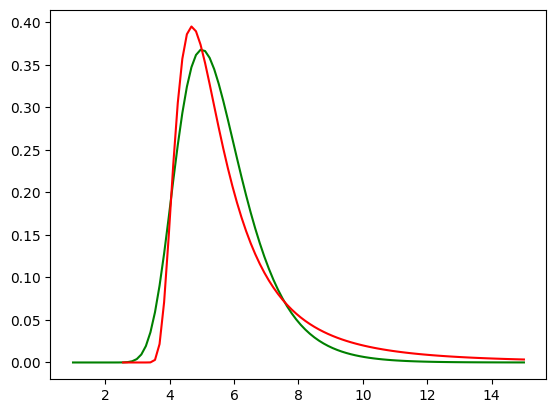

In [ ]:
ans = pdf(x,u,sigma,shape)

plt.plot(x,ans,color = 'green')
plt.plot(x,ans2,color = 'red')
plt.plot(x, n_d, color = 'blue')